In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_excel("P652-Dataset.xlsx")


In [3]:
df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [4]:
df.isnull().sum()


,0
title,0
rating,0
body,0


In [5]:
df['review'] = df['title'] + ' ' + df['body']

In [6]:
df.drop_duplicates(inplace=True)


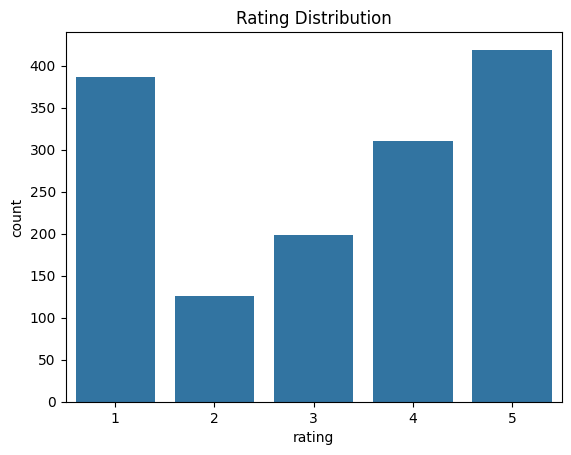

In [7]:
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()


In [8]:
df['rating'].value_counts(normalize=True)


,proportion
rating,
5,0.290972
1,0.268056
4,0.215278
3,0.138194
2,0.087500


In [9]:
df['char_count'] = df['review'].apply(len)


In [10]:
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))


In [11]:
df['avg_word_len'] = df['review'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()])
)


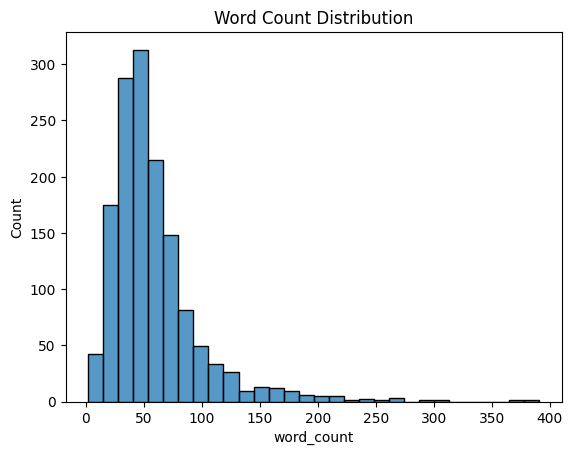

In [12]:
sns.histplot(df['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.show()


In [13]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [14]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [15]:
df['cleaned_review'] = df['review'].apply(preprocess_text)


In [16]:
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['cleaned_review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)


In [17]:
def categorize(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(categorize)


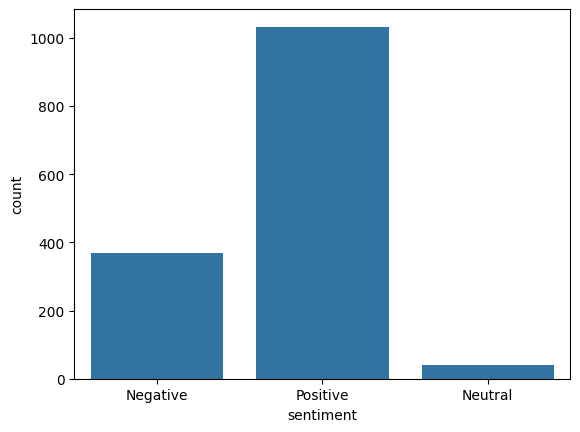

In [18]:
sns.countplot(x='sentiment', data=df)
plt.show()


In [19]:
X = df['cleaned_review']
y = df['sentiment']  # or use rating category

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [21]:
X_train_tfidf.shape


(1152, 5000)

In [26]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [27]:
y_pred = model.predict(X_test_tfidf)
accuracy_score(y_test, y_pred)


0.8784722222222222

In [28]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       0.83      0.74      0.78        68
     Neutral       0.00      0.00      0.00         7
    Positive       0.89      0.95      0.92       213

    accuracy                           0.88       288
   macro avg       0.57      0.56      0.57       288
weighted avg       0.86      0.88      0.87       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


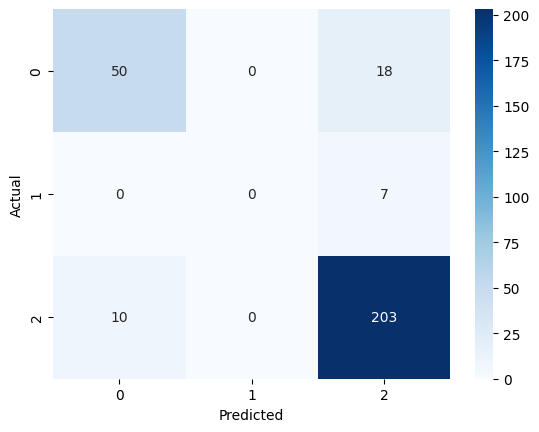

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
